# 1. Introduction

This project analyzes the Online Retail II dataset to explore sales performance, customer behavior, and retention patterns in a UK-based online retail business. The aim is to answer practical business questions and translate the results into actionable recommendations.


# 2. Dataset description

A real online retail transaction data set of two years.

Data Set Information:
This Online Retail II data set contains all the transactions occurring for a UK-based and registered, non-store online retail between 01/12/2009 and 09/12/2011.
The company mainly sells unique all-occasion gift-ware. Many customers of the company are wholesalers.

Attribute Information:
 - InvoiceNo: Invoice number. Nominal. A 6-digit integral number uniquely assigned to each transaction. If this code starts with the letter 'c', it indicates a cancellation.
 - StockCode: Product (item) code. Nominal. A 5-digit integral number uniquely assigned to each distinct product.
 - Description: Product (item) name. Nominal.
 - Quantity: The quantities of each product (item) per transaction. Numeric.
 - InvoiceDate: Invice date and time. Numeric. The day and time when a transaction was generated.
 - UnitPrice: Unit price. Numeric. Product price per unit in sterling (Â£).
 - CustomerID: Customer number. Nominal. A 5-digit integral number uniquely assigned to each customer.
 - Country: Country name. Nominal. The name of the country where a customer resides.

# 3. Data extraction

In [1]:
from kaggle.api.kaggle_api_extended import KaggleApi
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from pathlib import Path

sns.set_theme(style='whitegrid')


In [2]:
Path('data').mkdir(exist_ok=True)

file_path = Path('data/online_retail_II.xlsx')

if not file_path.exists():
    api = KaggleApi()
    api.authenticate()
    api.dataset_download_files(
        'lakshmi25npathi/online-retail-dataset',
        path='data',
        unzip=True
    )

df_2009_2010 = pd.read_excel(file_path, sheet_name='Year 2009-2010')
df_2010_2011 = pd.read_excel(file_path, sheet_name='Year 2010-2011')

df = pd.concat([df_2009_2010, df_2010_2011], ignore_index=True)


# 4. Data cleaning

Data Cleaning Steps:

 - Rename columns
 - Check dataset structure and data types
 - Remove duplicate rows
 - Create new columns for analysis
 - Prepare the dataset for downstream sales and customer analysis


### 4.1 Renaming columns.

In [3]:
df.head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom


Before starting the analysis, the column names were standardized to make later queries cleaner and less error-prone.


In [4]:
df.columns = df.columns.str.lower().str.replace(" ", "_")

df = df.rename(columns={"stockcode": 'stock_code', "invoicedate": 'invoice_date'})

The column names were converted to a consistent lowercase snake_case format to make the dataset easier to work with in Python.


### 4.2 Checking dataset structure and data types.

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1067371 entries, 0 to 1067370
Data columns (total 8 columns):
 #   Column        Non-Null Count    Dtype         
---  ------        --------------    -----         
 0   invoice       1067371 non-null  object        
 1   stock_code    1067371 non-null  object        
 2   description   1062989 non-null  object        
 3   quantity      1067371 non-null  int64         
 4   invoice_date  1067371 non-null  datetime64[ns]
 5   price         1067371 non-null  float64       
 6   customer_id   824364 non-null   float64       
 7   country       1067371 non-null  object        
dtypes: datetime64[ns](1), float64(2), int64(1), object(4)
memory usage: 65.1+ MB


Most columns already have suitable data types. The main exception is `customer_id`, which should be stored as an integer identifier rather than a float.


In [6]:
print(f"Summary all of values after point = {(df.customer_id % 1).sum()} It means, that all customer_id are integers, other values are NaN")

df['customer_id'] = df['customer_id'].astype('Int64')


Summary all of values after point = 0.0 It means, that all customer_id are integers, other values are NaN


`customer_id` was converted to a nullable integer type. This preserves missing values while treating the identifier as a proper customer key.


In [7]:
print(f"We have {df.shape[0] - df.drop_duplicates().shape[0]} duplicates, let's clear them.")

df = df.drop_duplicates()


We have 34335 duplicates, let's clear them.


### 4.4 Preparing dataset for future analysis.

In [8]:
df["invoice_month"] = df["invoice_date"].dt.to_period("M")
df["revenue"] = df["quantity"] * df["price"]

New columns `invoice_month` and `revenue` were added to support time-based analysis and sales metrics in later sections.


# 5. Exploratory data analysis
 - Dataset scope
 - Missing values
 - Transaction anomalies
 - Numeric distributions
 - Country structure
 - Product and order structure
 - Time coverage
 - Analytical subsets


### 5.1 Dataset scope.

In [9]:
print(f' \
Rows: {df.shape[0]}\n\n \
Dates between {str(df.invoice_month.min())} – {str(df.invoice_month.max())}\n\n \
Unique orders: {df.invoice.nunique()}\n \
Unique clients: {df.customer_id.nunique()}\n \
Unique items: {df.stock_code.nunique()}\n \
Unique countries: {df.country.nunique()}')


 Rows: 1033036

 Dates between 2009-12 – 2011-12

 Unique orders: 53628
 Unique clients: 5942
 Unique items: 5305
 Unique countries: 43


The dataset contains over 1 million transaction rows across two years. It includes a large number of products, customers, and countries, which makes it suitable for sales and customer analysis.

### 5.2 Missing values.


In [10]:
df.isna().sum()


invoice               0
stock_code            0
description        4275
quantity              0
invoice_date          0
price                 0
customer_id      235151
country               0
invoice_month         0
revenue               0
dtype: int64

Missing values are concentrated mainly in `customer_id`, while missing `description` values are relatively rare. This is important because customer-level analysis can only be performed on identified customers.


In [11]:
df.query("description.isna()").head()


,invoice,stock_code,description,quantity,invoice_date,price,customer_id,country,invoice_month,revenue
470,489521,21646,NaN,-50,2009-12-01 11:44:00,0.0,<NA>,United Kingdom,2009-12,-0.0
3114,489655,20683,NaN,-44,2009-12-01 17:26:00,0.0,<NA>,United Kingdom,2009-12,-0.0
3161,489659,21350,NaN,230,2009-12-01 17:39:00,0.0,<NA>,United Kingdom,2009-12,0.0
3731,489781,84292,NaN,17,2009-12-02 11:45:00,0.0,<NA>,United Kingdom,2009-12,0.0
4296,489806,18010,NaN,-770,2009-12-02 12:42:00,0.0,<NA>,United Kingdom,2009-12,-0.0


Rows with missing descriptions are mostly associated with zero price, missing customer IDs, and UK transactions. This suggests that many of them are operational records rather than standard product sales.


In [12]:
pd.Series({
    'Rows without customer ID': df['customer_id'].isna().sum(),
    'Share of rows without customer ID': round(df['customer_id'].isna().mean() * 100, 2),
    'Rows with missing description': df['description'].isna().sum()
}).to_frame('value')


,value
Rows without customer ID,235151.00
Share of rows without customer ID,22.76
Rows with missing description,4275.00


### 5.3 Transaction anomalies.


In [13]:
pd.Series({
    'Rows with positive revenue but missing customer ID': ((df['customer_id'].isna()) & (df['revenue'] > 0)).sum(),
    'Rows with non-positive quantity': (df['quantity'] <= 0).sum(),
    'Rows with negative price': (df['price'] < 0).sum(),
    'Invoices starting with C': df['invoice'].astype(str).str.startswith('C', na=False).sum(),
    'Rows with stock code M': (df['stock_code'].astype(str) == 'M').sum()
}).to_frame('count')


,count
Rows with positive revenue but missing customer ID,228489
Rows with non-positive quantity,22496
Rows with negative price,5
Invoices starting with C,19104
Rows with stock code M,1387


In [14]:
df.loc[~df['stock_code'].astype(str).str.contains(r'[0-9]', na=False), ['stock_code', 'description']] \
  .drop_duplicates() \
  .sort_values(['stock_code', 'description'])


,stock_code,description
208669,ADJUST,Adjustment by Peter on 24/05/2010 1
70975,ADJUST,Adjustment by john on 26/01/2010 16
71058,ADJUST,Adjustment by john on 26/01/2010 17
440688,AMAZONFEE,AMAZON FEE
179403,B,Adjust bad debt
18410,BANK CHARGES,Bank Charges
114180,BANK CHARGES,Bank Charges
842969,CRUK,CRUK Commission
735,D,Discount
89000,DCGSLBOY,NaN


The raw dataset contains cancellations, non-positive quantities, manual adjustments, and other non-product stock codes such as `POST`, `DOT`, `BANK CHARGES`, and `CRUK`. Some transactions without customer IDs still have positive revenue, which suggests that anonymous sales and operational records coexist in the raw data. These observations justify using separate analytical subsets later in the notebook.


### 5.4 Numeric distributions.


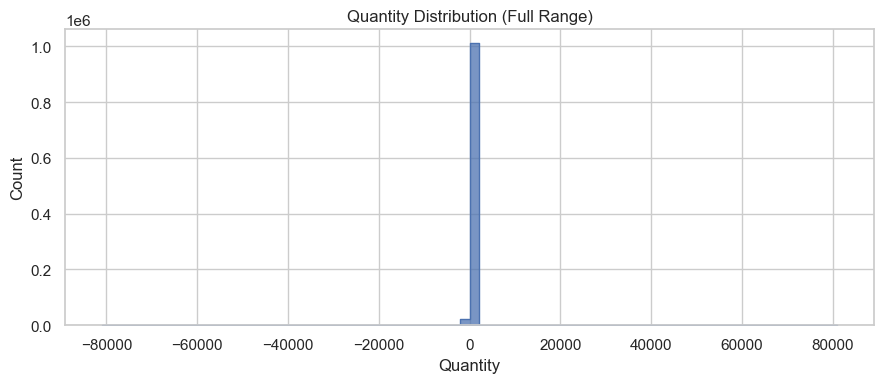

In [15]:
plt.figure(figsize=(9, 4))
sns.histplot(df['quantity'], bins=80, element='step', fill=True)
plt.title('Quantity Distribution (Full Range)')
plt.xlabel('Quantity')
plt.ylabel('Count')
plt.tight_layout()
plt.show()


The full-range quantity distribution is heavily skewed, so a narrower view is useful for understanding where most transactions are concentrated.


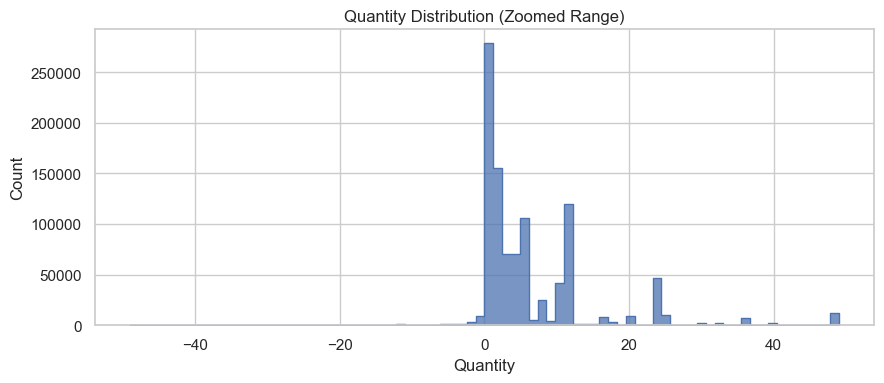

In [16]:
plt.figure(figsize=(9, 4))
sns.histplot(df.query('-50 < quantity < 50')['quantity'], bins=80, element='step')
plt.title('Quantity Distribution (Zoomed Range)')
plt.xlabel('Quantity')
plt.ylabel('Count')
plt.tight_layout()
plt.show()


Most transaction quantities are concentrated at relatively low values, with many purchases clustered in the low single digits.


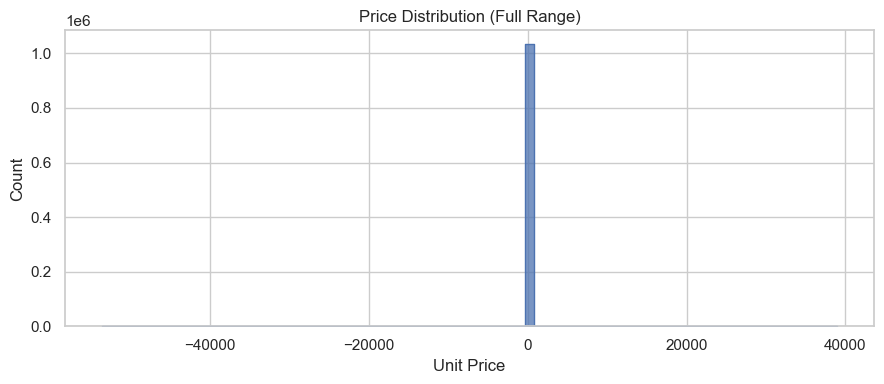

In [17]:
plt.figure(figsize=(9, 4))
sns.histplot(df['price'], bins=80, element='step', fill=True)
plt.title('Price Distribution (Full Range)')
plt.xlabel('Unit Price')
plt.ylabel('Count')
plt.tight_layout()
plt.show()


The full-range price distribution is also highly skewed, so it is useful to examine the central range separately.


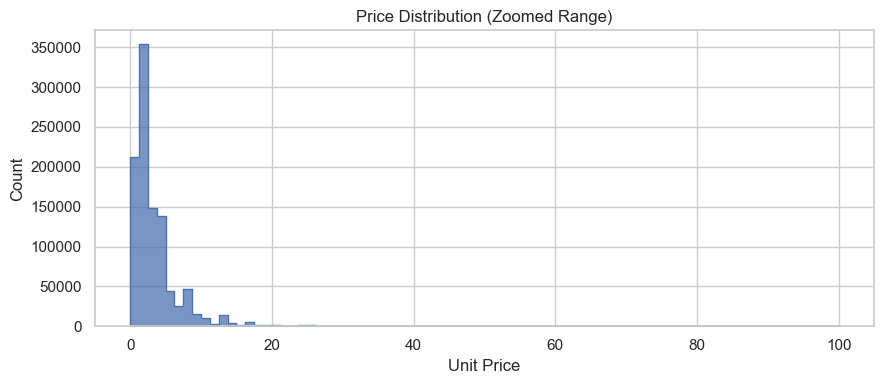

In [18]:
plt.figure(figsize=(9, 4))
sns.histplot(df.query('-100 < price < 100')['price'], bins=80, element='step')
plt.title('Price Distribution (Zoomed Range)')
plt.xlabel('Unit Price')
plt.ylabel('Count')
plt.tight_layout()
plt.show()


Negative prices are extremely rare, while most positive prices are concentrated at relatively low levels, especially below £5.


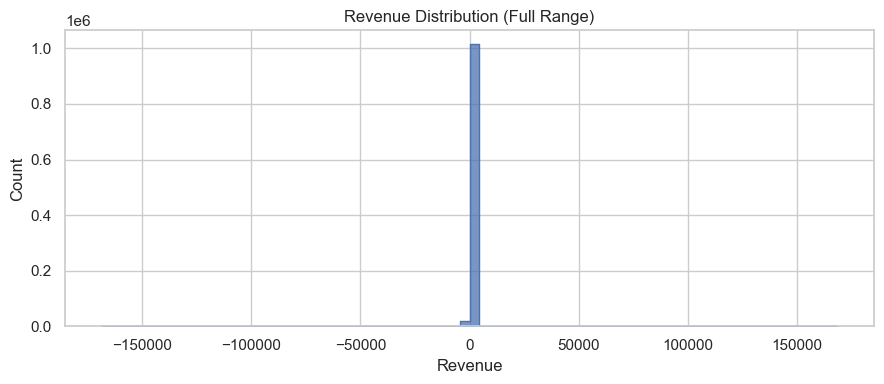

In [19]:
plt.figure(figsize=(9, 4))
sns.histplot(df['revenue'], bins=80, element='step', fill=True)
plt.title('Revenue Distribution (Full Range)')
plt.xlabel('Revenue')
plt.ylabel('Count')
plt.tight_layout()
plt.show()


Revenue shows the same skewed pattern as quantity and price, so a zoomed view provides a better sense of the typical transaction range.


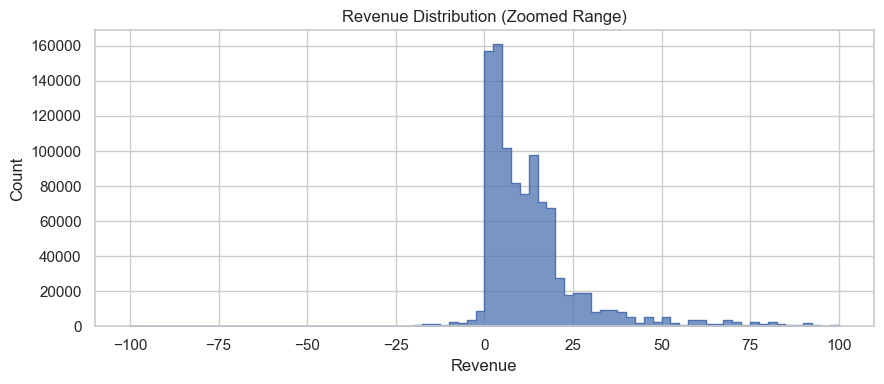

In [20]:
plt.figure(figsize=(9, 4))
sns.histplot(df.query('-100 < revenue < 100')['revenue'], bins=80, element='step')
plt.title('Revenue Distribution (Zoomed Range)')
plt.xlabel('Revenue')
plt.ylabel('Count')
plt.tight_layout()
plt.show()


Negative revenue exists but represents a relatively small share of all rows. Overall, the numeric variables are highly skewed and contain strong outliers, which is typical for transactional retail data. These distributions should be kept in mind when interpreting averages.


The skewed distributions suggest that median values and segmented views are often more informative than relying on averages alone.


In [21]:
df.country.value_counts().sort_values(ascending=False).head(10)


country
United Kingdom    948321
EIRE               17667
Germany            17339
France             14025
Netherlands         5137
Spain               3754
Switzerland         3175
Belgium             3110
Portugal            2528
Australia           1890
Name: count, dtype: int64

The UK has far more rows in the dataset than other countries, roughly an order of magnitude more, which suggests that most transactions and sales were likely concentrated in the UK.

In [22]:
df.query("country == 'United Kingdom'").shape[0] / df.shape[0]

0.9179941454121637

The United Kingdom dominates the dataset, so overall results are likely driven primarily by the UK market.


### 5.6. Product and order structure

In [23]:
df.loc[~df.stock_code.astype(str).str.contains(r"[0-9]", na=False)].stock_code.unique()



array(['POST', 'D', 'DOT', 'M', 'BANK CHARGES', 'PADS', 'ADJUST',
       'DCGSSGIRL', 'GIFT', 'DCGSLBOY', 'm', 'DCGSSBOY', 'DCGSLGIRL', 'S',
       'B', 'AMAZONFEE', 'CRUK'], dtype=object)

In [24]:
df.stock_code.nunique()


5305

There are 5305 unique stock codes. Only 17 of them consist only of letters.


In [25]:
df.stock_code.value_counts().sort_values(ascending=False).head(10)

stock_code
85123A    5653
22423     4306
85099B    4132
21212     3209
20725     3170
84879     2870
47566     2733
21232     2666
22383     2469
22197     2465
Name: count, dtype: int64

The most frequent stock codes represent the products that appear most often in transactions, which helps identify the store's most commonly purchased items.


In [26]:
df.groupby('invoice').agg({'invoice_date': 'count'}).sort_values('invoice_date', ascending=False).head(10)


,invoice_date
invoice,
573585,1114
581219,749
581492,731
580729,721
558475,705
579777,687
581217,676
537434,675
580730,662


Several invoices contain a large number of line items, which indicates that large orders are not isolated cases in this dataset.


In [27]:
df.groupby('invoice').agg({'quantity': 'sum'}).sort_values('quantity', ascending=False).head(10)


,quantity
invoice,
524174,87167
518505,87167
497946,83774
581483,80995
541431,74215
501534,63974
495194,63302
502269,40000
493819,25018


Some orders include very high product quantities, which may reflect wholesale purchasing behavior.


### 5.7. Time coverage.


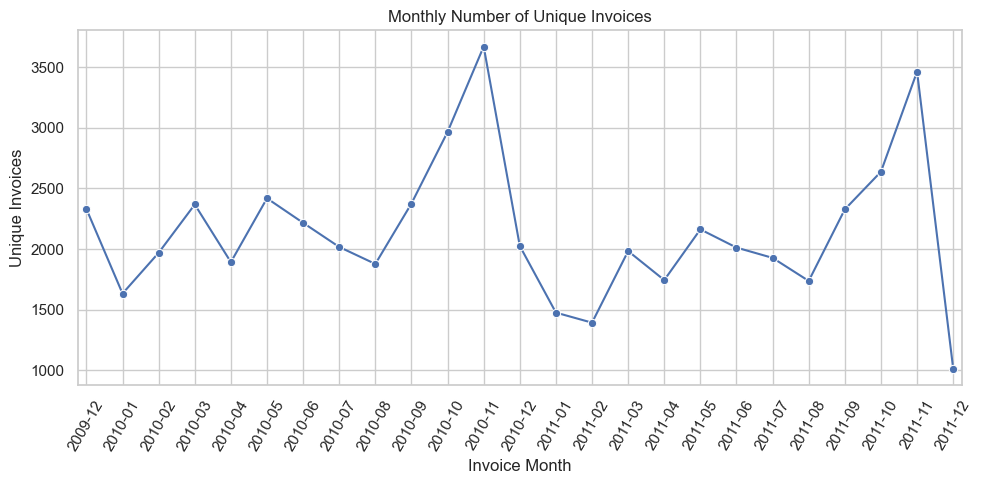

In [28]:
plt.figure(figsize=(10, 5))
monthly_orders = (
    df.groupby('invoice_month', as_index=False)
      .agg(invoice_nunique=('invoice', 'nunique'))
      .sort_values('invoice_month')
      .assign(invoice_month=lambda d: d['invoice_month'].astype(str))
)
ax = sns.lineplot(data=monthly_orders, x='invoice_month', y='invoice_nunique', marker='o')
ax.set_title('Monthly Number of Unique Invoices')
ax.set_xlabel('Invoice Month')
ax.set_ylabel('Unique Invoices')
ax.margins(x=0.01)
plt.xticks(rotation=60)
plt.tight_layout()
plt.show()


Transaction activity peaks in November in both years, which may reflect holiday-season demand. The final month in the dataset is incomplete, so it should be interpreted carefully in time-based analysis.


### 5.8. Analytical subsets.


In [29]:
df_sales = df[
    (df['quantity'] > 0) &
    (df['price'] > 0) &
    (~df['invoice'].astype(str).str.contains(r'[A-Za-z]', na=False)) &
    (~df['stock_code'].astype(str).str.fullmatch(r'[A-Za-z]+', na=False))
].copy()

df_customers = df_sales[df_sales['customer_id'].notna()].copy()


To keep the analysis consistent, separate analytical subsets were created for sales metrics and customer-level analysis.


# 6. Sales analysis

 - Total revenue
 - Monthly revenue trend
 - Top products by revenue
 - Top countries by revenue
 - Average order value


### 6.1 Total revenue


In [30]:
df_sales.revenue.sum()


19659973.100999992

Total revenue is 19 659 973 pounds.


### 6.2 Monthly revenue trend


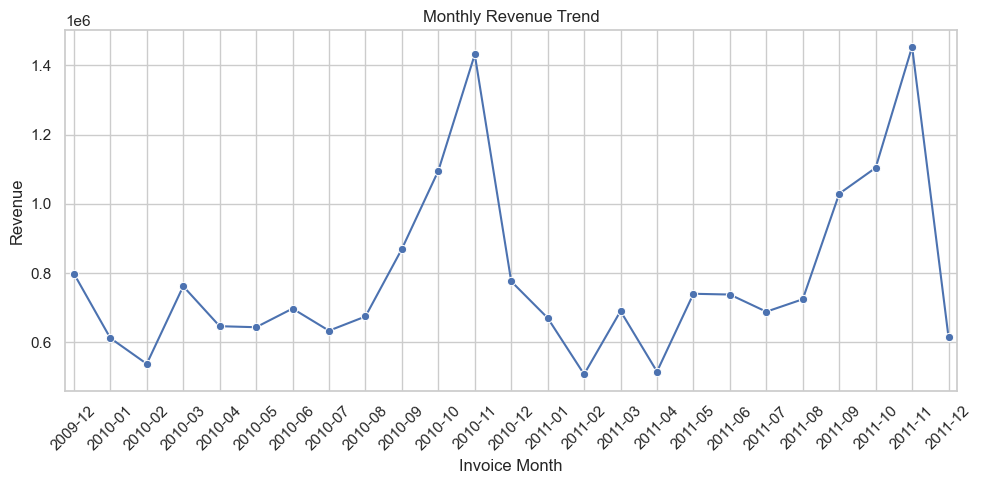

In [31]:
plt.figure(figsize=(10, 5))
monthly_revenue = (
    df_sales.groupby('invoice_month', as_index=False)
            .agg(revenue=('revenue', 'sum'))
            .sort_values('invoice_month')
            .assign(invoice_month=lambda d: d['invoice_month'].astype(str))
)
ax = sns.lineplot(data=monthly_revenue, x='invoice_month', y='revenue', marker='o')
ax.set_title('Monthly Revenue Trend')
ax.set_xlabel('Invoice Month')
ax.set_ylabel('Revenue')
ax.margins(x=0.01)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


Monthly revenue generally follows transaction activity, with clear peaks in November and a drop in the incomplete final month.


### 6.3 Top products by revenue


In [32]:
df_sales.groupby('stock_code', as_index=False) \
    .agg({'description': 'first', 'revenue': 'sum'}) \
    .sort_values('revenue', ascending=False) \
    .head(10) \
    .style.hide(axis='index')


stock_code,description,revenue
22423,REGENCY CAKESTAND 3 TIER,330590.320000
85123A,WHITE HANGING HEART T-LIGHT HOLDER,257724.710000
85099B,JUMBO BAG RED WHITE SPOTTY,180569.340000
23843,"PAPER CRAFT , LITTLE BIRDIE",168469.600000
47566,PARTY BUNTING,148318.280000
84879,ASSORTED COLOUR BIRD ORNAMENT,129324.490000
22086,PAPER CHAIN KIT 50'S CHRISTMAS,117760.290000
23166,MEDIUM CERAMIC TOP STORAGE JAR,81700.920000
79321,CHILLI LIGHTS,80540.880000
22197,"POPCORN HOLDER , SMALL",79520.200000


Among individual products, REGENCY CAKESTAND 3 TIER generated the highest revenue in the analyzed period.


### 6.4 Top countries by revenue


In [33]:
df_sales.groupby('country', as_index=False) \
    .agg({'revenue': 'sum'}) \
    .sort_values('revenue', ascending=False) \
    .head(10) \
    .style.hide(axis='index')


country,revenue
United Kingdom,16806564.851000
EIRE,633284.160000
Netherlands,549773.410000
Germany,383289.000000
France,311486.290000
Australia,167800.010000
Spain,97766.750000
Switzerland,94024.590000
Sweden,86319.140000
Denmark,67422.690000


The United Kingdom generates the highest revenue by a wide margin, while the rest of the top 10 markets are mostly European countries.


### 6.5 Average order value


In [34]:
df_sales.revenue.sum() / df_sales.invoice.nunique()


496.85291771336125

The average order value is about 500 pounds, calculated as total revenue divided by the number of unique invoices in the cleaned sales dataset.


# 7. Customer analysis
 - Customer base overview
 - Revenue per customer
 - Order frequency per customer
 - New vs returning customers
 - Top customers / customer concentration
 - Customer segmentation by value


### 7.1 Customer base overview


In [35]:
print(f"""
Unique customers: {df_customers['customer_id'].nunique()}
Unique orders: {df_customers['invoice'].nunique()}
Transactions: {df_customers.shape[0]}
Average orders per customer: {df_customers['invoice'].nunique() / df_customers['customer_id'].nunique():.2f}
""")



Unique customers: 5853
Unique orders: 36643
Transactions: 776871
Average orders per customer: 6.26



The customer-level dataset contains 5,853 unique customers and 36,643 orders. On average, each identified customer placed about 6.26 orders during the observed period. However, customer-level analysis excludes transactions without customer IDs, which account for a notable share of the dataset.


### 7.2 Revenue per customer


In [36]:
df_revenue_per_customer = df_customers.groupby('customer_id', as_index=False) \
    .agg(
        total_revenue=('revenue', 'sum'),
        total_orders=('invoice', 'nunique'),
        total_quantity=('quantity', 'sum'),
        unique_countries=('country', 'max')
    ) \
    .sort_values('total_revenue', ascending=False)

df_revenue_per_customer.head(10).style.hide(axis='index')


customer_id,total_revenue,total_orders,total_quantity,unique_countries
18102,580987.040000,145,181645,United Kingdom
14646,526751.520000,145,367072,Netherlands
14156,304719.880000,145,164314,EIRE
14911,279492.790000,376,147950,EIRE
17450,244784.250000,51,83914,United Kingdom
13694,195640.690000,143,188201,United Kingdom
17511,172132.870000,60,117174,United Kingdom
16446,168472.500000,2,80997,United Kingdom
16684,147142.770000,55,104810,United Kingdom
12415,144033.370000,24,91443,Australia


The top customer generated nearly 581k pounds in revenue over the two-year period. The top 10 customers include buyers from several countries, suggesting that high-value customers are not limited to the UK only.


In [37]:
df_revenue_per_customer.total_revenue.describe()


count      5853.000000
mean       2918.594869
std       14335.595400
min           2.950000
25%         340.850000
50%         856.030000
75%        2240.900000
max      580987.040000
Name: total_revenue, dtype: float64

Customer revenue is unevenly distributed: a small group of customers generates a disproportionately large share of total revenue.


### 7.3 Order frequency per customer


In [38]:
df_revenue_per_customer.total_orders.value_counts().sort_index().head(10)


total_orders
1     1619
2      942
3      659
4      490
5      354
6      280
7      218
8      173
9      154
10      97
Name: count, dtype: int64

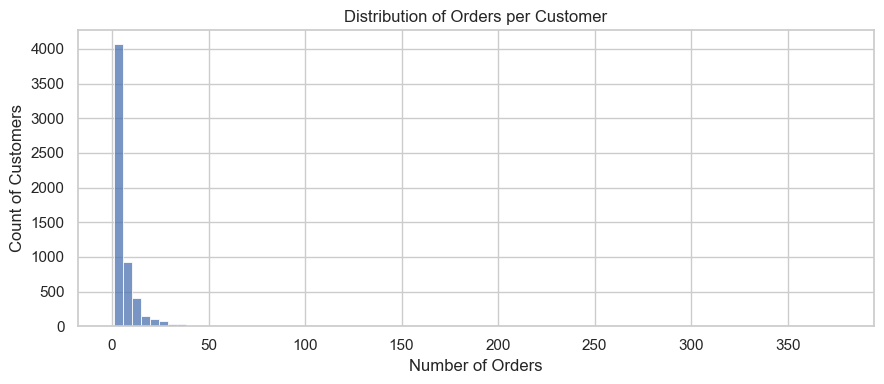

In [39]:
plt.figure(figsize=(9, 4))
sns.histplot(df_revenue_per_customer['total_orders'], bins=80)
plt.title('Distribution of Orders per Customer')
plt.xlabel('Number of Orders')
plt.ylabel('Count of Customers')
plt.tight_layout()
plt.show()


Most customers place only a small number of orders, while a smaller segment returns repeatedly.


### 7.4 New vs returning customers


In [40]:
first_purchase = df_customers.groupby('customer_id', as_index=False) \
                                .agg(first_purchase_month=('invoice_month', 'min'))

df_customers = pd.merge(df_customers, first_purchase, on='customer_id', how='left')

df_customers['customer_type'] = np.where(
    df_customers['invoice_month'] > df_customers['first_purchase_month'], 'Returning', 'New'
)

monthly_customer_type = df_customers.groupby(['invoice_month', 'customer_type'], as_index=False) \
    .agg(customer_cnt=('customer_id', 'nunique'))

monthly_customer_type


,invoice_month,customer_type,customer_cnt
0,2009-12,New,952
1,2010-01,New,368
2,2010-01,Returning,334
3,2010-02,New,375
4,2010-02,Returning,396
5,2010-03,New,440
6,2010-03,Returning,611
7,2010-04,New,294
8,2010-04,Returning,647
9,2010-05,New,255


Returning customers consistently outnumber new customers after the initial months, which suggests that repeat purchasing is an important driver of the business.


### 7.5 Top customers / customer concentration


In [41]:
top_5_threshold = df_revenue_per_customer.total_revenue.quantile(0.95)

top_5_df = df_revenue_per_customer[df_revenue_per_customer.total_revenue >= top_5_threshold]

top_5_df.total_revenue.sum() / df_revenue_per_customer.total_revenue.sum()


0.5199720362991535

The top 5% of customers generate about 52% of total revenue. This indicates a strong concentration of revenue among a relatively small group of buyers.


### 7.6 Customer segmentation by value


In [42]:
df_revenue_per_customer['segment'] = pd.qcut(
    df_revenue_per_customer.total_revenue,
    q=4,
    labels=['Low', 'Mid-Low', 'Mid-High', 'High']
)


In [43]:
df_revenue_per_customer.groupby('segment', as_index=False, observed=True) \
        .agg(
            customer_cnt=('customer_id', 'nunique'),
            revenue_per_group=('total_revenue', 'sum')
        ) \
        .style.hide(axis='index')


segment,customer_cnt,revenue_per_group
Low,1464,281637.760000
Mid-Low,1463,823683.680000
Mid-High,1463,2051967.671000
High,1463,13925246.660000


Customer segmentation by revenue shows that value is not distributed evenly across the customer base. The higher-value segments contribute a disproportionately large share of total revenue.


# 8. Cohort / retention analysis
- Calculate cohort index
- Build cohort table
- Calculate retention rate
- Visualize retention heatmap

### 8.1 Calculate cohort index

In [44]:
df_customers['cohort_index'] = (
    (df_customers['invoice_month'].dt.year - df_customers['first_purchase_month'].dt.year) * 12 +
    (df_customers['invoice_month'].dt.month - df_customers['first_purchase_month'].dt.month)
)

The cohort index shows how many months have passed since each customer’s first purchase.

### 8.2 Build cohort table

In [45]:
cohort_data = df_customers.groupby(['first_purchase_month', 'cohort_index'], as_index=False) \
                            .agg(customer_cnt = ('customer_id', 'nunique'))

cohort_counts = cohort_data.pivot(
    index='first_purchase_month',
    columns='cohort_index',
    values='customer_cnt'
)

cohort_counts


cohort_index,0,1,2,3,4,5,6,7,8,9,...,15,16,17,18,19,20,21,22,23,24
first_purchase_month,,,,,,,,,,,,,,,,,,,,,
2009-12,952.0,334.0,317.0,405.0,362.0,342.0,360.0,327.0,321.0,344.0,...,288.0,250.0,288.0,270.0,246.0,242.0,299.0,289.0,386.0,187.0
2010-01,368.0,79.0,118.0,116.0,100.0,115.0,99.0,86.0,105.0,120.0,...,56.0,90.0,75.0,71.0,74.0,93.0,73.0,93.0,21.0,NaN
2010-02,375.0,88.0,85.0,110.0,92.0,74.0,72.0,108.0,96.0,104.0,...,76.0,60.0,61.0,54.0,86.0,86.0,62.0,22.0,NaN,NaN
2010-03,440.0,84.0,102.0,106.0,103.0,90.0,110.0,135.0,122.0,48.0,...,75.0,77.0,69.0,78.0,90.0,94.0,35.0,NaN,NaN,NaN
2010-04,294.0,56.0,56.0,47.0,54.0,65.0,81.0,78.0,31.0,32.0,...,46.0,41.0,44.0,53.0,67.0,17.0,NaN,NaN,NaN,NaN
2010-05,255.0,40.0,43.0,45.0,45.0,65.0,54.0,32.0,15.0,21.0,...,32.0,35.0,42.0,39.0,12.0,NaN,NaN,NaN,NaN,NaN
2010-06,267.0,47.0,50.0,55.0,62.0,76.0,34.0,24.0,22.0,30.0,...,33.0,35.0,54.0,13.0,NaN,NaN,NaN,NaN,NaN,NaN
2010-07,186.0,29.0,34.0,55.0,54.0,26.0,21.0,27.0,27.0,21.0,...,32.0,44.0,15.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2010-08,163.0,32.0,47.0,53.0,27.0,19.0,16.0,21.0,22.0,21.0,...,32.0,12.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


### 8.3 Calculate retention rate


In [46]:
cohort_sizes = cohort_counts.iloc[:, 0]

retention = cohort_counts.divide(cohort_sizes, axis=0)

Retention rate is calculated as the share of customers from each cohort who returned in later months, relative to the cohort size in month 0.


### 8.4 Visualize retention heatmap

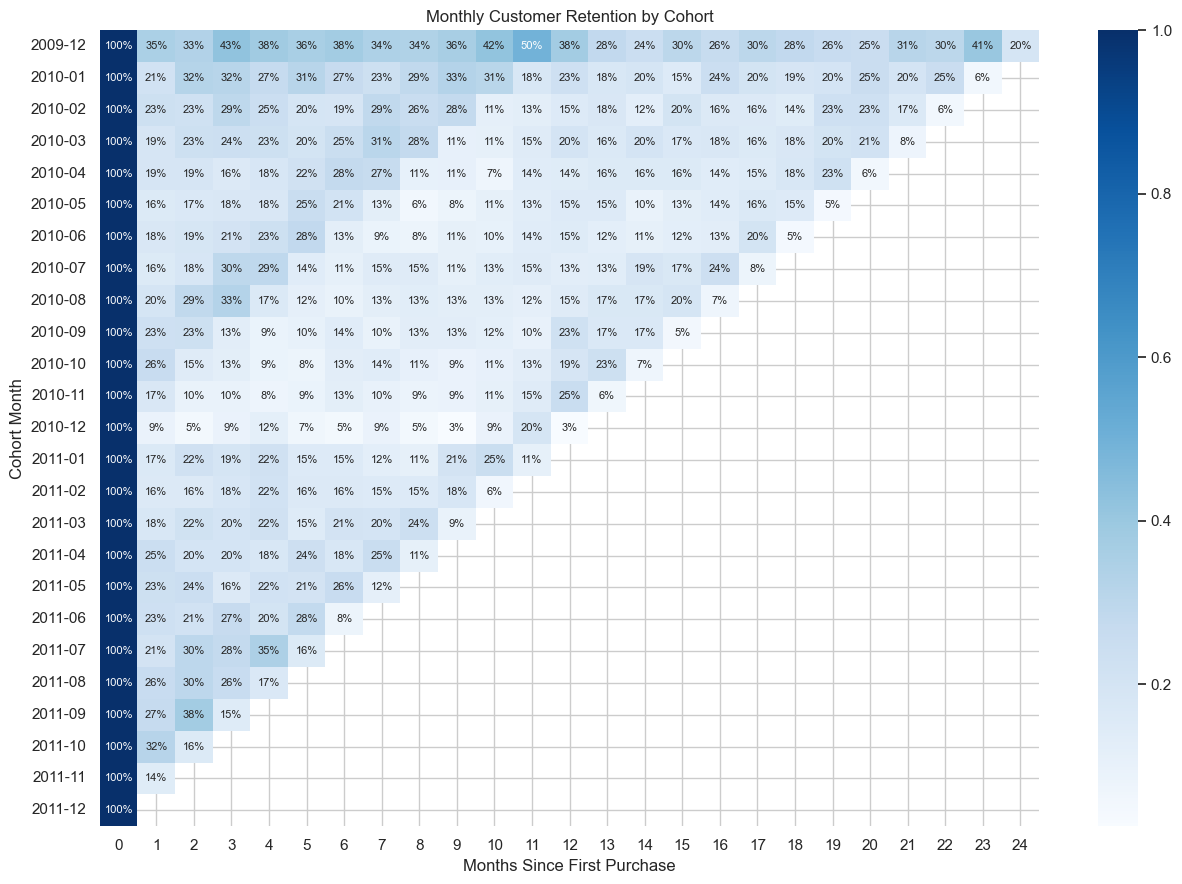

In [47]:
plt.figure(figsize=(13, 9))
sns.heatmap(
    retention,
    annot=True,
    fmt='.0%',
    cmap='Blues',
    annot_kws={'size': 8}
)
plt.title('Monthly Customer Retention by Cohort')
plt.xlabel('Months Since First Purchase')
plt.ylabel('Cohort Month')
plt.tight_layout()
plt.show()


The cohort heatmap shows that retention is highest in the first months after acquisition and then generally declines over time. Some cohorts retain customers better than others, and the December 2009 cohort appears stronger than many later cohorts. Retention also does not decline perfectly smoothly, which suggests that customers often return irregularly rather than every month. Recent cohorts should be interpreted carefully because they have fewer follow-up months in the dataset.


# 9. Business insights

1. The business is highly concentrated in the UK market. Most transactions and revenue come from the United Kingdom, so overall performance is driven primarily by domestic demand.

2. Sales show clear seasonality, with both transaction activity and revenue peaking in November. This suggests that the business benefits strongly from the holiday shopping period.

3. Customer value is highly concentrated. The top 5% of customers generate about 52% of total revenue, which indicates strong dependence on a relatively small group of high-value buyers.

4. Returning customers play an important role in the business. Many customers place only a few orders, but repeat buyers account for a substantial share of ongoing activity and long-term revenue.

5. Order sizes vary significantly, and some invoices include very large quantities. This supports the assumption that part of the customer base behaves more like wholesalers than typical retail shoppers.

6. The dataset includes cancellations, manual adjustments, and transactions without customer IDs. These records need to be handled carefully, because they can distort both sales and customer metrics.


# 10. Recommendations

1. Prioritize retention of high-value customers. Since a small share of customers generates a large share of revenue, keeping these buyers engaged should be a major business priority.

2. Improve second-purchase conversion. Many customers place only a few orders, so targeted follow-up campaigns after the first purchase could help move more buyers into the repeat-customer segment.

3. Prepare early for seasonal demand peaks. Because revenue rises strongly in November, inventory, promotions, and operations should be planned in advance of the holiday period.

4. Develop separate strategies for wholesale-like and regular customers. Large order sizes suggest that different customer types may require different pricing, communication, or service approaches.

5. Improve customer identification and transaction labeling. More complete customer IDs and clearer labeling of operational transactions would support more accurate analysis and better business decisions.


# 11. Conclusion

This project analyzed a two-year online retail dataset to understand sales performance, customer behavior, and retention patterns. The analysis showed that the business is strongly concentrated in the UK market, experiences clear seasonal peaks, and depends heavily on repeat customers and a relatively small group of high-value buyers. These findings suggest that customer retention, seasonal planning, and better customer segmentation could play an important role in supporting future revenue growth.
